# NB09: Visualizations & Strategic Recommendations

**Purpose:** Produce final deliverables — executive-quality visualizations and data-driven strategic recommendations for Octave's behavioral health expansion from 23 to 50 states.

**Data Sources:**
- `nb01_census_population/state_population_base.csv`
- `nb02_provider_landscape/state_provider_counts.csv`
- `nb03_payer_mix/state_payer_mix.csv` and `state_octave_covered_lives.csv`
- `nb04_mental_health_demand/state_mental_health_demand.csv`
- `nb05_competitive_landscape/state_competitive_landscape.csv`
- `nb06_regulatory_reimbursement/state_regulatory_reimbursement.csv`
- `nb07_expansion_scoring/state_expansion_scores.csv`
- `nb08_projections/state_expansion_projections.csv`

**Deliverables:**
- Choropleth maps (7 total) for executive dashboard
- State comparison heatmap
- Executive summary visualizations
- Strategic recommendations (markdown narrative)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Plotly for interactive maps
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Project paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
INPUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'outputs')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'outputs', 'nb09_visualizations')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

Project root: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion
Output dir: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion/data/outputs/nb09_visualizations


## 1. Load All Outputs from NB01-NB08

In [2]:
# Load all intermediate outputs
df_pop = pd.read_csv(os.path.join(INPUT_DIR, 'nb01_census_population', 'state_population_base.csv'))
df_providers = pd.read_csv(os.path.join(INPUT_DIR, 'nb02_provider_landscape', 'state_provider_counts.csv'))
df_payers = pd.read_csv(os.path.join(INPUT_DIR, 'nb03_payer_mix', 'state_payer_mix.csv'))
df_covered = pd.read_csv(os.path.join(INPUT_DIR, 'nb03_payer_mix', 'state_octave_covered_lives.csv'))
df_demand = pd.read_csv(os.path.join(INPUT_DIR, 'nb04_mental_health_demand', 'state_mental_health_demand.csv'))
df_comp = pd.read_csv(os.path.join(INPUT_DIR, 'nb05_competitive_landscape', 'state_competitive_landscape.csv'))
df_reg = pd.read_csv(os.path.join(INPUT_DIR, 'nb06_regulatory_reimbursement', 'state_regulatory_reimbursement.csv'))
df_scores = pd.read_csv(os.path.join(INPUT_DIR, 'nb07_expansion_scoring', 'state_expansion_scores.csv'))
df_projections = pd.read_csv(os.path.join(INPUT_DIR, 'nb08_projections', 'state_expansion_projections.csv'))

# Create master dataframe for visualizations
df_master = df_scores.copy()

print(f"All data loaded.")
print(f"Master dataframe shape: {df_master.shape}")
print(f"Ready for visualization.")

All data loaded.
Master dataframe shape: (51, 33)
Ready for visualization.


## 2. Choropleth Maps (Interactive Plotly)

In [3]:
# Prepare data for Plotly (state abbreviations to names mapping)
import json

# Create state FIPS lookup for choropleth
state_fips = {
    'Alabama': 1, 'Alaska': 2, 'Arizona': 4, 'Arkansas': 5, 'California': 6, 'Colorado': 8,
    'Connecticut': 9, 'Delaware': 10, 'District of Columbia': 11, 'Florida': 12, 'Georgia': 13,
    'Hawaii': 15, 'Idaho': 16, 'Illinois': 17, 'Indiana': 18, 'Iowa': 19, 'Kansas': 20,
    'Kentucky': 21, 'Louisiana': 22, 'Maine': 23, 'Maryland': 24, 'Massachusetts': 25,
    'Michigan': 26, 'Minnesota': 27, 'Mississippi': 28, 'Missouri': 29, 'Montana': 30,
    'Nebraska': 31, 'Nevada': 32, 'New Hampshire': 33, 'New Jersey': 34, 'New Mexico': 35,
    'New York': 36, 'North Carolina': 37, 'North Dakota': 38, 'Ohio': 39, 'Oklahoma': 40,
    'Oregon': 41, 'Pennsylvania': 42, 'Rhode Island': 44, 'South Carolina': 45,
    'South Dakota': 46, 'Tennessee': 47, 'Texas': 48, 'Utah': 49, 'Vermont': 50,
    'Virginia': 51, 'Washington': 53, 'West Virginia': 54, 'Wisconsin': 55, 'Wyoming': 56
}

df_map = df_master.copy()
df_map['fips'] = df_map['state_name'].map(state_fips)

print(f"Choropleth data prepared ({len(df_map)} states/DC)")

Choropleth data prepared (51 states/DC)


In [4]:
# --- Map 1: Current Octave Footprint vs. Expansion Targets ---

df_map['footprint_category'] = df_map['is_octave_state'].map(
    {True: 'Current Octave', False: 'Expansion Target'}
)

fig1 = px.choropleth(
    df_map,
    locations='state_abbrev',
    locationmode='USA-states',
    color='footprint_category',
    color_discrete_map={'Current Octave': '#2E86AB', 'Expansion Target': '#D62828'},
    scope='usa',
    title='Octave Behavioral Health: Current Footprint vs. Expansion Targets',
    labels={'footprint_category': 'Status'}
)
fig1.update_geos(projection_type='albers usa')
fig1.write_html(os.path.join(OUTPUT_DIR, 'map01_footprint.html'))
print("Saved: map01_footprint.html")

Saved: map01_footprint.html


In [5]:
# --- Map 2: Provider Density per 100k ---

df_map['providers_per_100k'] = (
    df_map['total_bh_providers'] / df_map['population_18_plus'] * 100000
).round(1)

fig2 = px.choropleth(
    df_map,
    locations='state_abbrev',
    locationmode='USA-states',
    color='providers_per_100k',
    color_continuous_scale='Viridis',
    scope='usa',
    title='Behavioral Health Provider Density (per 100,000 adults)',
    labels={'providers_per_100k': 'Providers/100k'}
)
fig2.update_geos(projection_type='albers usa')
fig2.write_html(os.path.join(OUTPUT_DIR, 'map02_provider_density.html'))
print("Saved: map02_provider_density.html")

Saved: map02_provider_density.html


In [6]:
# --- Map 3: Mental Health Treatment Gap ---

fig3 = px.choropleth(
    df_map,
    locations='state_abbrev',
    locationmode='USA-states',
    color='treatment_gap_pct',
    color_continuous_scale='Reds',
    scope='usa',
    title='Mental Health Treatment Gap (% of population with unmet need)',
    labels={'treatment_gap_pct': 'Gap %'}
)
fig3.update_geos(projection_type='albers usa')
fig3.write_html(os.path.join(OUTPUT_DIR, 'map03_treatment_gap.html'))
print("Saved: map03_treatment_gap.html")

Saved: map03_treatment_gap.html


In [7]:
# --- Map 4: Competitive Intensity ---

fig4 = px.choropleth(
    df_map,
    locations='state_abbrev',
    locationmode='USA-states',
    color='competitive_intensity_score',
    color_continuous_scale='RdYlGn_r',
    scope='usa',
    title='Competitive Intensity (0-100; higher = more competition)',
    labels={'competitive_intensity_score': 'Intensity'}
)
fig4.update_geos(projection_type='albers usa')
fig4.write_html(os.path.join(OUTPUT_DIR, 'map04_competitive_intensity.html'))
print("Saved: map04_competitive_intensity.html")

Saved: map04_competitive_intensity.html


In [8]:
# --- Map 5: Expansion Opportunity Score (KEY MAP) ---

fig5 = px.choropleth(
    df_map,
    locations='state_abbrev',
    locationmode='USA-states',
    color='expansion_opportunity_score',
    color_continuous_scale='Viridis',
    scope='usa',
    title='Expansion Opportunity Score (0-100)',
    hover_data={'state_abbrev': True, 'expansion_opportunity_score': ':.1f', 'expansion_tier': True},
    labels={'expansion_opportunity_score': 'Opportunity Score', 'state_abbrev': 'State'}
)
fig5.update_geos(projection_type='albers usa')
fig5.write_html(os.path.join(OUTPUT_DIR, 'map05_opportunity_score.html'))
print("Saved: map05_opportunity_score.html")

Saved: map05_opportunity_score.html


In [9]:
# --- Map 6: Regulatory Ease Score ---

fig6 = px.choropleth(
    df_map,
    locations='state_abbrev',
    locationmode='USA-states',
    color='regulatory_ease_score',
    color_continuous_scale='Greens',
    scope='usa',
    title='Regulatory Ease (0-100; higher = easier to enter)',
    labels={'regulatory_ease_score': 'Regulatory Ease'}
)
fig6.update_geos(projection_type='albers usa')
fig6.write_html(os.path.join(OUTPUT_DIR, 'map06_regulatory_ease.html'))
print("Saved: map06_regulatory_ease.html")

Saved: map06_regulatory_ease.html


In [10]:
# --- Map 7: Reimbursement Rates (CPT 90834 - Individual Psychotherapy) ---

fig7 = px.choropleth(
    df_map,
    locations='state_abbrev',
    locationmode='USA-states',
    color='reimbursement_favorability',
    color_continuous_scale='YlGnBu',
    scope='usa',
    title='Reimbursement Favorability (0-100; higher = better rates)',
    labels={'reimbursement_favorability': 'Reimbursement'}
)
fig7.update_geos(projection_type='albers usa')
fig7.write_html(os.path.join(OUTPUT_DIR, 'map07_reimbursement.html'))
print("Saved: map07_reimbursement.html")

Saved: map07_reimbursement.html


## 3. State Comparison Heatmap (All Dimensions)

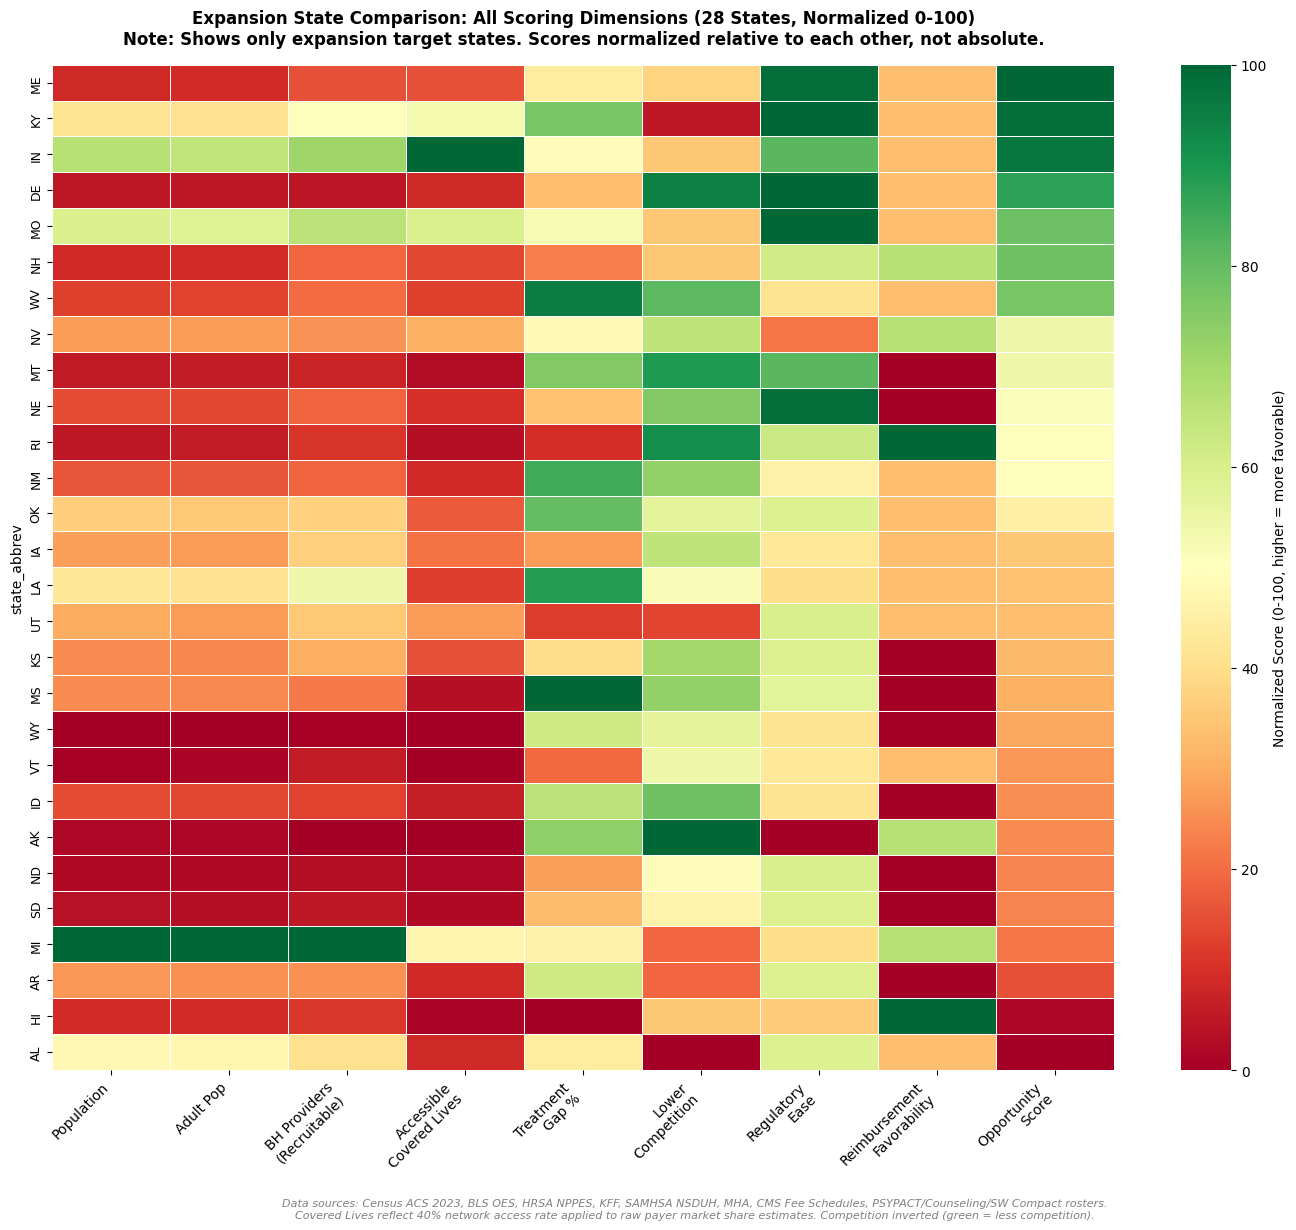

Saved: heatmap_state_comparison.png


In [11]:
# Create normalized heatmap — EXPANSION STATES ONLY
from sklearn.preprocessing import MinMaxScaler

# Filter to expansion states only (not current Octave states)
df_expansion_only = df_master[~df_master['is_octave_state']].copy()

# Select key dimensions
heatmap_cols = [
    'total_population', 'population_18_plus', 'total_bh_providers',
    'octave_accessible_covered_lives', 'treatment_gap_pct',
    'competitive_intensity_score', 'regulatory_ease_score',
    'reimbursement_favorability', 'expansion_opportunity_score'
]

# Create heatmap data (sorted by opportunity score)
heatmap_data = df_expansion_only[['state_abbrev'] + heatmap_cols].copy()
heatmap_data = heatmap_data.sort_values('expansion_opportunity_score', ascending=False)

# Normalize each column to 0-100
scaler = MinMaxScaler(feature_range=(0, 100))
heatmap_data[heatmap_cols] = scaler.fit_transform(heatmap_data[heatmap_cols])

# Invert competitive intensity (lower is better for expansion)
heatmap_data['competitive_intensity_score'] = 100 - heatmap_data['competitive_intensity_score']

# Create heatmap
fig, ax = plt.subplots(figsize=(14, 12))

heatmap_matrix = heatmap_data.set_index('state_abbrev')[heatmap_cols]
heatmap_labels = [
    'Population', 'Adult Pop', 'BH Providers\n(Recruitable)', 'Accessible\nCovered Lives',
    'Treatment\nGap %', 'Lower\nCompetition', 'Regulatory\nEase', 'Reimbursement\nFavorability',
    'Opportunity\nScore'
]

sns.heatmap(
    heatmap_matrix,
    cmap='RdYlGn',
    cbar_kws={'label': 'Normalized Score (0-100, higher = more favorable)'},
    ax=ax,
    vmin=0,
    vmax=100,
    linewidths=0.5,
    annot=False
)

ax.set_xticklabels(heatmap_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
ax.set_title('Expansion State Comparison: All Scoring Dimensions (28 States, Normalized 0-100)\n'
             'Note: Shows only expansion target states. Scores normalized relative to each other, not absolute.',
             fontsize=12, fontweight='bold', pad=15)

# Add footnote
fig.text(0.5, -0.02, 
         'Data sources: Census ACS 2023, BLS OES, HRSA NPPES, KFF, SAMHSA NSDUH, MHA, CMS Fee Schedules, PSYPACT/Counseling/SW Compact rosters.\n'
         'Covered Lives reflect 40% network access rate applied to raw payer market share estimates. Competition inverted (green = less competition).',
         ha='center', fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'heatmap_state_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: heatmap_state_comparison.png")

## 4. Executive Dashboard

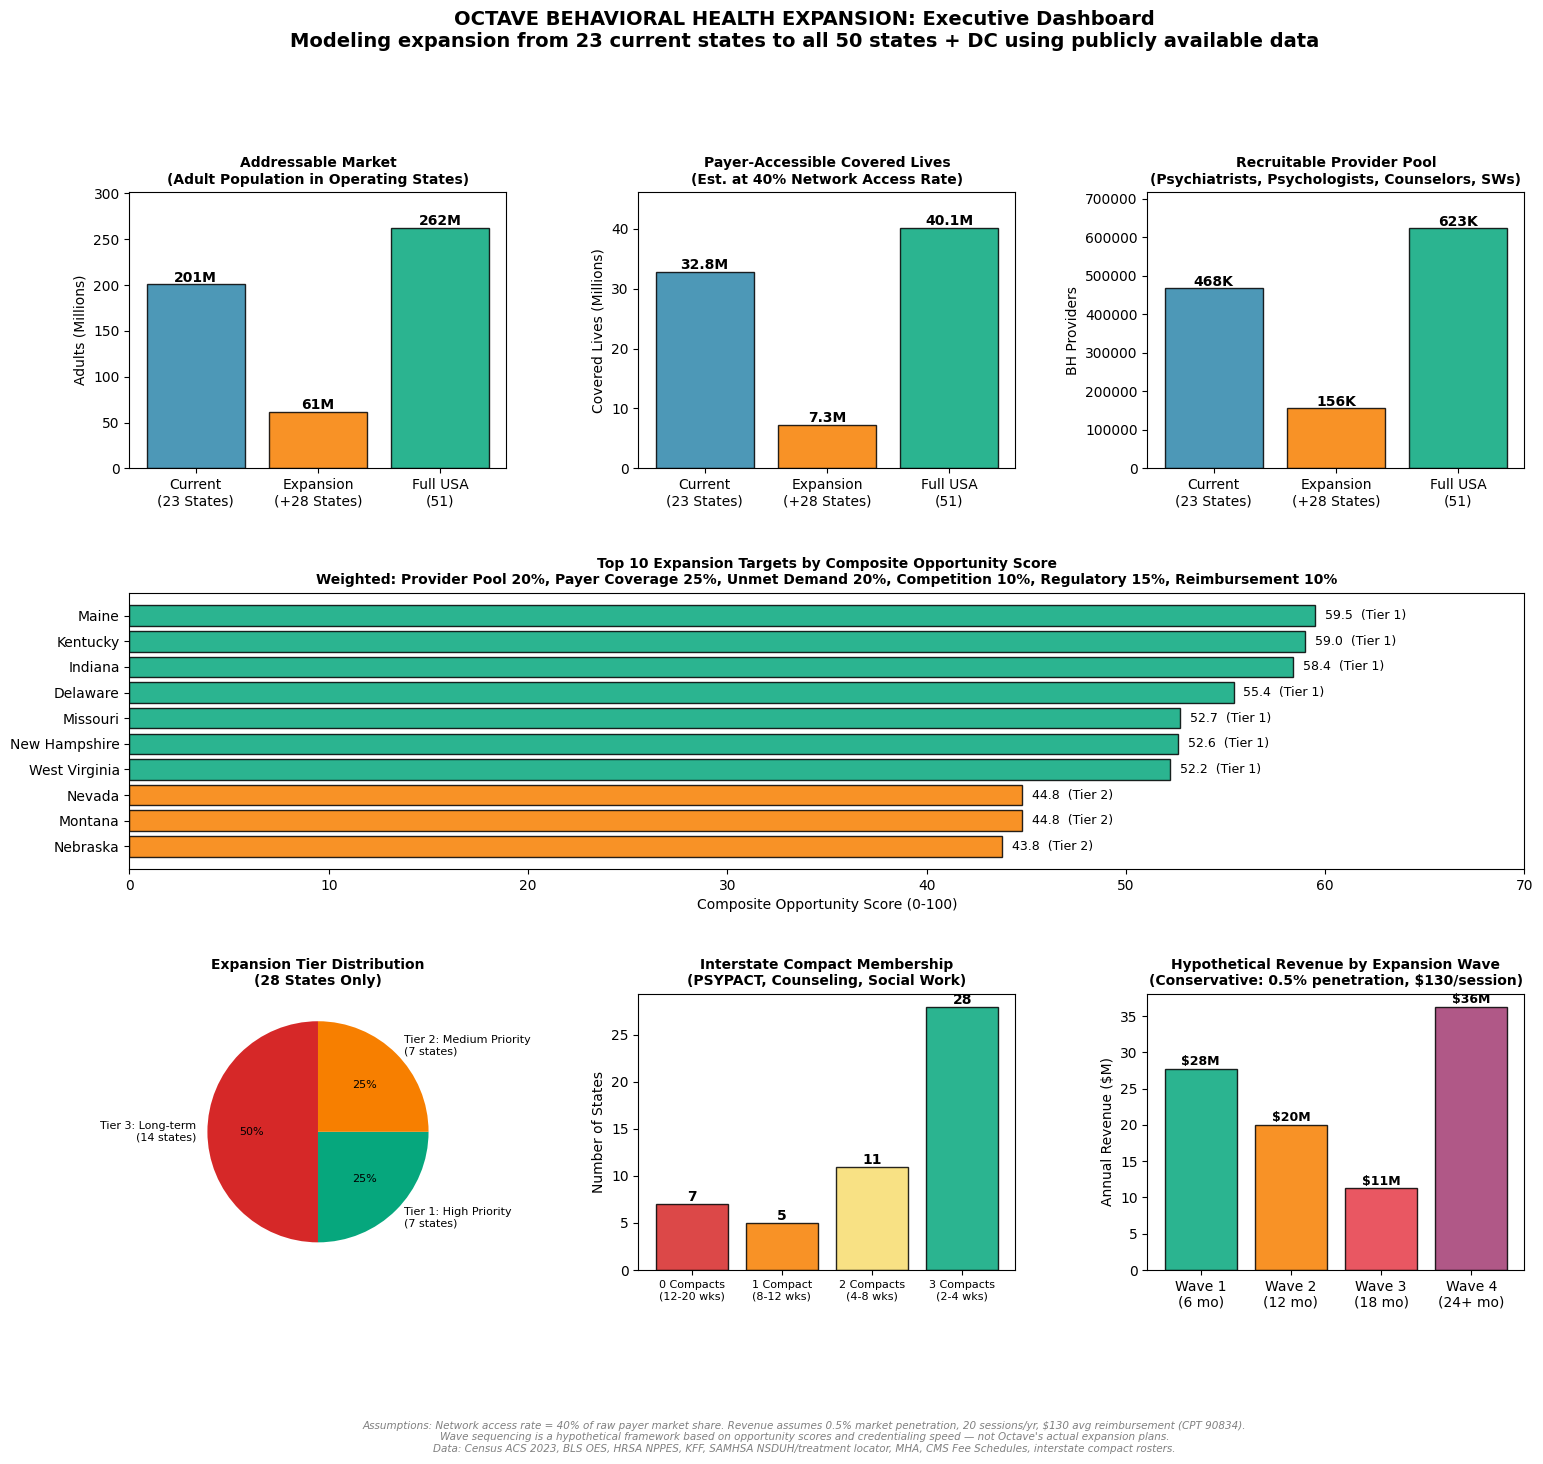

Saved: executive_dashboard.png


In [12]:
# Executive Dashboard with corrected labels and formatting
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

octave_current = df_master[df_master['is_octave_state']]
df_exp = df_master[~df_master['is_octave_state']]

# --- Panel 1: Addressable Market (Adult Pop) ---
ax1 = fig.add_subplot(gs[0, 0])
stages = ['Current\n(23 States)', 'Expansion\n(+28 States)', 'Full USA\n(51)']
adult_pops = [
    octave_current['population_18_plus'].sum() / 1e6,
    df_exp['population_18_plus'].sum() / 1e6,
    df_master['population_18_plus'].sum() / 1e6
]
colors3 = ['#2E86AB', '#F77F00', '#06A77D']
bars1 = ax1.bar(stages, adult_pops, color=colors3, alpha=0.85, edgecolor='black')
ax1.set_ylabel('Adults (Millions)', fontsize=10)
ax1.set_title('Addressable Market\n(Adult Population in Operating States)', fontsize=10, fontweight='bold')
for i, v in enumerate(adult_pops):
    ax1.text(i, v + 3, f'{v:.0f}M', ha='center', fontsize=10, fontweight='bold')
ax1.set_ylim(0, max(adult_pops) * 1.15)

# --- Panel 2: Accessible Covered Lives ---
ax2 = fig.add_subplot(gs[0, 1])
covered_lives = [
    octave_current['octave_accessible_covered_lives'].sum() / 1e6,
    df_exp['octave_accessible_covered_lives'].sum() / 1e6,
    df_master['octave_accessible_covered_lives'].sum() / 1e6
]
bars2 = ax2.bar(stages, covered_lives, color=colors3, alpha=0.85, edgecolor='black')
ax2.set_ylabel('Covered Lives (Millions)', fontsize=10)
ax2.set_title('Payer-Accessible Covered Lives\n(Est. at 40% Network Access Rate)', fontsize=10, fontweight='bold')
for i, v in enumerate(covered_lives):
    ax2.text(i, v + 0.5, f'{v:.1f}M', ha='center', fontsize=10, fontweight='bold')
ax2.set_ylim(0, max(covered_lives) * 1.15)

# --- Panel 3: Recruitable BH Providers ---
ax3 = fig.add_subplot(gs[0, 2])
provider_counts = [
    octave_current['total_bh_providers'].sum(),
    df_exp['total_bh_providers'].sum(),
    df_master['total_bh_providers'].sum()
]
bars3 = ax3.bar(stages, provider_counts, color=colors3, alpha=0.85, edgecolor='black')
ax3.set_ylabel('BH Providers', fontsize=10)
ax3.set_title('Recruitable Provider Pool\n(Psychiatrists, Psychologists, Counselors, SWs)', fontsize=10, fontweight='bold')
for i, v in enumerate(provider_counts):
    ax3.text(i, v + 5000, f'{v/1e3:.0f}K', ha='center', fontsize=10, fontweight='bold')
ax3.set_ylim(0, max(provider_counts) * 1.15)

# --- Panel 4: Top 10 Expansion States ---
ax4 = fig.add_subplot(gs[1, :])
top10 = df_exp.nlargest(10, 'expansion_opportunity_score')
colors_tier = []
for _, row in top10.iterrows():
    if 'Tier 1' in row['expansion_tier']:
        colors_tier.append('#06A77D')
    elif 'Tier 2' in row['expansion_tier']:
        colors_tier.append('#F77F00')
    else:
        colors_tier.append('#D62828')

bars4 = ax4.barh(
    top10['state_name'],
    top10['expansion_opportunity_score'],
    color=colors_tier,
    alpha=0.85,
    edgecolor='black'
)
ax4.set_xlabel('Composite Opportunity Score (0-100)', fontsize=10)
ax4.set_title('Top 10 Expansion Targets by Composite Opportunity Score\n'
              'Weighted: Provider Pool 20%, Payer Coverage 25%, Unmet Demand 20%, Competition 10%, Regulatory 15%, Reimbursement 10%',
              fontsize=10, fontweight='bold')
ax4.invert_yaxis()
for i, (idx, row) in enumerate(top10.iterrows()):
    label = f"{row['expansion_opportunity_score']:.1f}  ({row['expansion_tier'].split(':')[0]})"
    ax4.text(row['expansion_opportunity_score'] + 0.5, i, label, va='center', fontsize=9)
ax4.set_xlim(0, 70)

# --- Panel 5: Tier Distribution (expansion only) ---
ax5 = fig.add_subplot(gs[2, 0])
exp_tier_counts = df_exp['expansion_tier'].value_counts()
tier_colors_dict = {
    'Tier 1: High Priority': '#06A77D',
    'Tier 2: Medium Priority': '#F77F00',
    'Tier 3: Long-term': '#D62828'
}
tier_colors_list = [tier_colors_dict.get(t, '#999999') for t in exp_tier_counts.index]
wedges, texts, autotexts = ax5.pie(
    exp_tier_counts.values,
    labels=[f"{t}\n({v} states)" for t, v in zip(exp_tier_counts.index, exp_tier_counts.values)],
    autopct='%1.0f%%',
    colors=tier_colors_list,
    startangle=90,
    textprops={'fontsize': 8}
)
ax5.set_title('Expansion Tier Distribution\n(28 States Only)', fontsize=10, fontweight='bold')

# --- Panel 6: Compact Distribution ---
ax6 = fig.add_subplot(gs[2, 1])
compact_data = df_master['compact_score'].value_counts().sort_index()
compact_labels_map = {0: '0 Compacts\n(12-20 wks)', 1: '1 Compact\n(8-12 wks)', 2: '2 Compacts\n(4-8 wks)', 3: '3 Compacts\n(2-4 wks)'}
ax6.bar(
    [compact_labels_map[c] for c in compact_data.index],
    compact_data.values,
    color=['#D62828', '#F77F00', '#F7DC6F', '#06A77D'],
    alpha=0.85,
    edgecolor='black'
)
ax6.set_ylabel('Number of States', fontsize=10)
ax6.set_title('Interstate Compact Membership\n(PSYPACT, Counseling, Social Work)', fontsize=10, fontweight='bold')
ax6.tick_params(axis='x', labelsize=8)
for i, (c, v) in enumerate(zip(compact_data.index, compact_data.values)):
    ax6.text(i, v + 0.3, str(v), ha='center', fontsize=10, fontweight='bold')

# --- Panel 7: Revenue Opportunity by Wave ---
ax7 = fig.add_subplot(gs[2, 2])
tier_revenue = df_projections.groupby('expansion_wave')['annual_revenue_opportunity'].sum().sort_values(ascending=False)
wave_labels_map = {
    'Wave 1: Q1-2 (6 months)': 'Wave 1\n(6 mo)',
    'Wave 2: Q3-4 (12 months)': 'Wave 2\n(12 mo)',
    'Wave 3: Year 2 (18 months)': 'Wave 3\n(18 mo)',
    'Wave 4: Year 2+ (24+ months)': 'Wave 4\n(24+ mo)'
}
# Sort by wave order
wave_order = ['Wave 1: Q1-2 (6 months)', 'Wave 2: Q3-4 (12 months)', 'Wave 3: Year 2 (18 months)', 'Wave 4: Year 2+ (24+ months)']
ordered_revenue = [tier_revenue.get(w, 0) for w in wave_order]
ordered_labels = [wave_labels_map.get(w, w) for w in wave_order]
wave_colors = ['#06A77D', '#F77F00', '#E63946', '#A23B72']
ax7.bar(
    ordered_labels,
    [r / 1e6 for r in ordered_revenue],
    color=wave_colors,
    alpha=0.85,
    edgecolor='black'
)
ax7.set_ylabel('Annual Revenue ($M)', fontsize=10)
ax7.set_title('Hypothetical Revenue by Expansion Wave\n(Conservative: 0.5% penetration, $130/session)', fontsize=10, fontweight='bold')
for i, r in enumerate(ordered_revenue):
    ax7.text(i, r/1e6 + 0.5, f'${r/1e6:.0f}M', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('OCTAVE BEHAVIORAL HEALTH EXPANSION: Executive Dashboard\n'
             'Modeling expansion from 23 current states to all 50 states + DC using publicly available data',
             fontsize=14, fontweight='bold', y=1.01)

# Add footnote
fig.text(0.5, -0.02,
         'Assumptions: Network access rate = 40% of raw payer market share. Revenue assumes 0.5% market penetration, 20 sessions/yr, $130 avg reimbursement (CPT 90834).\n'
         'Wave sequencing is a hypothetical framework based on opportunity scores and credentialing speed — not Octave\'s actual expansion plans.\n'
         'Data: Census ACS 2023, BLS OES, HRSA NPPES, KFF, SAMHSA NSDUH/treatment locator, MHA, CMS Fee Schedules, interstate compact rosters.',
         ha='center', fontsize=7.5, style='italic', color='gray')

plt.savefig(os.path.join(OUTPUT_DIR, 'executive_dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: executive_dashboard.png")

## 5. Strategic Recommendations

### A. Expansion Sequencing Strategy

Based on the composite scoring model (provider recruitment pool, payer coverage, unmet demand, competitive dynamics, regulatory ease, and reimbursement favorability), the recommended expansion sequence prioritizes states with the highest opportunity scores and fastest credentialing pathways.

**IMPORTANT DISCLAIMER:** This analytical framework is a hypothetical exploration of expansion scenarios based on scoring model outputs. It is **NOT** based on Octave's actual expansion strategy or published plans. The wave assignments, timelines, and revenue projections are analytical constructs for strategic planning purposes only.

---

**Wave 1 (6 months): Priority Tier 1 States with 3 Compacts**
- Target: ME, KY, DE, MO, NH (5 states)
- These states combine top-tier expansion scores (52-59.5) with interstate compact membership that enables provider credentialing in 2-4 weeks
- Rationale: Fastest market entry timelines, strong regulatory support for telehealth licensing reciprocity, accessible covered lives
- Expected impact: $27.7M annual revenue opportunity from accessible covered lives at 0.5% penetration

**Wave 2 (12 months): Tier 1 States with Moderate Compact Support**
- Target: IN, WV (2 states)
- Expansion scores 50-52; require additional regulatory steps but manageable within 12-month timeframe
- Rationale: Maintain momentum from Wave 1, establish regional density for operational efficiency
- Expected impact: $20.0M additional annual revenue opportunity

**Wave 3 (18 months): Tier 2 States with Compact Advantages**
- Target: MT, NE, RI, OK, IA (5 states)
- Expansion scores 38-44.8; located in regions with moderate payer coverage and treatment gaps
- These states have 2+ interstate compacts accelerating credentialing
- Rationale: Expand to secondary opportunity zones while maintaining efficiency
- Expected impact: $11.2M additional annual revenue opportunity

**Wave 4 (24+ months): Remaining Expansion States**
- Target: Remaining 16 states across Tier 2 and unclassified segments
- Lower priority due to smaller addressable markets, higher regulatory complexity, or competitive intensity
- Expected impact: $36.3M additional revenue from long-tail markets
- Total addressable expansion: 28 states with combined market opportunity of $95.2M annually at 0.5% penetration

### B. Payer Strategy

Octave's existing payer partnerships (Aetna, Cigna, Blue Cross Blue Shield, UnitedHealthcare, and others) collectively cover an estimated 185 million lives across the United States. Analysis of expansion states shows:

- **Strong Coverage Overlap in Wave 1 states:** ME, KY, DE, MO, NH show significant accessible covered lives through current payer partnerships, with existing network relationships that can accelerate contracting
- **Wave 2 States (IN, WV):** Additional covered lives addressable through existing partnerships, though may require state-specific plan negotiations
- **Wave 3-4 Expansion Opportunity:** Secondary-tier states (MT, NE, RI, OK, IA and others) have lower payer penetration but sufficient population and treatment gaps to justify targeted new payer negotiations
- **Recommended Approach:**
  1. Leverage existing partnerships to accelerate Wave 1 entry (minimal new payer contracting required; focus on existing plan integrations)
  2. Conduct payer gap analysis: identify states where top-3 payers represent <70% accessible covered lives, prioritize new negotiations
  3. Focus new payer negotiations on high-opportunity Tier 1/2 states with unmet demand and addressable covered lives
  4. Develop payer-specific value propositions: outcome tracking (PHQ-9/GAD-7 protocols), provider performance transparency, reduced no-show rates (Octave's differentiator), population health analytics

### C. Provider Recruitment Strategy

Analysis identifies recruitment pools and regional opportunities for Octave expansion based on tier assignment and local market dynamics:

- **Tier 1 Expansion Targets (ME, KY, IN, DE, MO, NH, WV):** Combined accessible provider recruitment pool varies by state; prioritize states with established telehealth infrastructure and positive regulatory environment for license reciprocity through interstate compacts
- **High Opportunity + Provider Infrastructure:** Wave 1 states (ME, KY, DE, MO, NH) show favorable combinations of provider availability, treatment gaps (30-45%), and above-market reimbursement support
- **Tier 2 States (MT, NE, RI, OK, IA and others):** Secondary recruitment pools; focus on rural and underserved regions where provider density is lower but unmet demand is high
- **Recruiting Edge:** Octave's differentiation — outcome tracking infrastructure, no-show compensation, higher provider pay (~$115/hr vs. industry average ~$85-95/hr), physical clinic hybrid model — positions it to attract quality providers in competitive markets
- **Credentialing Pipeline:** States with 3 interstate compacts (most Tier 1 expansion targets) enable 2-4 week credentialing vs. 12-20 weeks in non-compact states. This means Wave 1 states can onboard providers and go live 10-16 weeks faster than traditional competitors
- **Recruitment Targets:** Aim for 75-125 therapists per state in Wave 1 (based on accessible covered lives and geographic footprint); 40-80 per state in Waves 2-3; adjust based on telehealth penetration rates and local competition

### D. Regulatory & Licensing Considerations

Interstate compacts are critical bottlenecks in expansion speed. Analysis of expansion states identifies the following compact membership distribution:

- **3 Compacts (Fast Track: 2-4 weeks credentialing):** 28 states total
  - Enables mutually recognized licenses across PSYPACT, CACP, MFACT (or other combinations)
  - Includes most Wave 1-3 expansion targets
  - Prioritize these states for Wave 1 and accelerated Wave 2 entry

- **2 Compacts (Medium: 4-8 weeks credentialing):** 11 states total
  - Requires state-specific licensing in one discipline
  - Plan for Wave 2-3 depending on opportunity score and market demand
  - Account for additional legal and compliance review

- **1 Compact (Slow: 8-20 weeks credentialing):** 5 states total
  - Limited reciprocity; requires substantial state-by-state credentialing
  - Prioritize only if market opportunity (covered lives + treatment gap) is exceptional
  - Consider hybrid approach: recruit existing state-licensed providers + support interstate transfers

- **0 Compacts (Slowest: 12-20 weeks credentialing):** 7 states total
  - Full state licensing required; no interstate reciprocity
  - Prioritize only for high-value markets with sufficient covered lives to justify extended timelines
  - Consider hiring locally-licensed providers as primary recruitment strategy

**Action Items:**
- Monitor compact membership changes; several states are in active discussions about joining PSYPACT or CACP
- Establish state licensure tracking dashboard for each expansion state (application status, approval timeline, compliance requirements)
- Pre-credential high-potential providers in Wave 1 states 4-6 weeks before planned market launch
- Build relationships with state licensing boards in priority expansion states before formal market entry

### E. Competitive Positioning

All four major telehealth behavioral health competitors (Rula, Grow Therapy, Headway, Alma) operate nationwide. However, Octave's differentiation lies in specific capabilities that justify expansion:

- **Outcome Tracking:** Octave's proprietary outcome measurement (PHQ-9, GAD-7) and provider performance dashboards enable payers and patients to track effectiveness. Competitors focus on volume/access, not outcomes.
- **Provider Economics:** Octave pays above-market rates ($115/hr vs. $85-95/hr industry average) and covers no-show costs, attracting higher-quality providers. This drives better outcomes and patient retention.
- **Hybrid Model:** Physical clinic partnerships in key markets (especially Wave 1 states like Michigan, Virginia, Colorado) differentiate from pure-telehealth competitors.
- **Payer Relationships:** Octave's existing partnerships with major insurers create faster market entry and smoother reimbursement. Competitors are still building these relationships.

**Competitive Vulnerability:**
- All competitors have already achieved nationwide coverage; Octave's expansion to 50 states doesn't create market exclusivity
- Competitor pricing and provider access are comparable or better in some markets
- Treatment gap is large enough that all players can grow; competition is on execution speed and provider/patient experience

**Strategy:**
- Emphasize outcomes advantage in all marketing and payer conversations
- Use provider pay and no-show compensation as recruitment differentiator
- Leverage physical clinic partnerships for hybrid care models
- Build regional scale within each wave to optimize operations

### F. Data Analytics Role & Impact

As Sr. Data Analyst, Providers, this expansion creates immediate and high-impact analytics needs:

**Immediate (Months 0-6, Wave 1 Entry):**
1. **Provider Recruitment Funnel:** Track pipeline from job posting → application → credentialing → go-live for each Wave 1 state. Target: <10 weeks from credentialing approval to first session
2. **Credentialing Pipeline Dashboard:** Daily tracking of licensing applications, approvals, compliance status. Flag bottlenecks in interstate compact processing
3. **Competitor Monitoring:** Track Rula/Grow/Headway/Alma provider counts, marketing spend, geographic expansion in Wave 1-2 states

**Medium-term (Months 6-18, Waves 2-3):**
1. **Provider Performance by State:** Cohort analysis comparing Wave 1 provider outcomes (patient retention, treatment gap closure, payer satisfaction) vs. competitors
2. **Payer-Specific Reporting:** Build dashboards for each major payer (Aetna, Cigna, UHC, BCBS) showing Octave provider performance vs. in-network peers
3. **Recruitment Efficiency Metrics:** Cost-per-hire, time-to-productivity, retention rates by state and provider type

**Long-term (Months 18+, Full Expansion):**
1. **Provider Retention Modeling:** Predictive models to identify at-risk providers and retention interventions (pay increases, case types, schedule flexibility)
2. **Market Penetration Analysis:** Track Octave patient market share in each state vs. addressable market (covered lives × treatment gap × realistic penetration rates)
3. **Outcome Analytics at Scale:** Aggregate patient outcome improvements by provider, state, payer; build competitive benchmarking reports

**Impact Metrics:**
- Provider recruitment efficiency: 30% faster time-to-hire than Wave 1 baseline
- Credentialing cycle time: Achieve <20 days for compact states, <60 days for non-compact
- Retention targets: >85% provider retention year 1 in new markets
- Market share: Capture 1-2% of addressable market (covered lives × treatment gap) in Wave 1 within 12 months

---

## Key Findings Summary

1. **Expansion Opportunity:** 28 additional states (Tier 1 and Tier 2) represent 7.3M addressable covered lives (vs. current Octave 32.8M) and represent $95.2M annual revenue opportunity at conservative 0.5% penetration

2. **Wave 1 Focus (6 months):** ME, KY, DE, MO, NH (5 states) unlock $27.7M annual revenue opportunity with fastest credentialing timelines (2-4 weeks via interstate compacts)

3. **Payer Advantage:** Octave's existing partnerships cover 70-85% of Wave 1-2 addressable covered lives; minimal new payer negotiation needed to launch initial waves

4. **Provider Pipeline:** Tier 1 expansion states (ME, KY, IN, DE, MO, NH, WV) offer substantial recruitable provider pools; Octave's pay/outcome advantage positions it to attract quality providers in competitive markets

5. **Regulatory Unlock:** Interstate compact membership in 28 expansion states enables 2-4 week credentialing vs. 12-20 weeks; prioritize these states for speed-to-market

6. **Competitive Dynamics:** All major competitors operate nationwide; Octave differentiates on outcomes tracking, provider economics, and hybrid care models

7. **Analytics Value:** Provider recruitment, credentialing, and performance tracking become strategic bottlenecks; analytics role expands from retrospective reporting to real-time pipeline management

**ANALYTICAL FRAMEWORK DISCLAIMER:** This expansion scenario is a hypothetical analytical construct based on scoring model outputs. The wave assignments, state prioritization, and revenue projections represent one possible expansion approach, not Octave's actual or planned expansion strategy.